# ddharmon v2 — Split-Aware Harmonization to the NIH CDE Backbone

End-to-end harmonization of biomedical data-dictionary fields to NIH **Common Data Elements (CDEs)**, run
over the public example dictionaries bundled in `data/examples/` using the `ddharmon` `src` modules.

**The v2 pipeline (lean, split-aware):**
1. **Cluster** the cohort fields (BERTopic: UMAP → HDBSCAN).
2. **Retrieve** candidate CDEs per cluster — hybrid lexical (BM25) ⊕ dense (cosine), fused with RRF.
3. **Generate-ideal** — an LLM writes the *ideal* CDE each cluster wants (a coverage anchor).
4. **Split** — partition each cluster into distinct-concept groups on the object/referent axis.
5. **Assign** — per group, the LLM ranks the retrieved CDEs and decides **adopt / refine / novel**.
6. **Route** — adopt/refine → the matched CDE; novel → a GenCDE residual. A retrieval floor downgrades
   geometrically-far "matches" to novel.

Encoder: **BioLORD-2023** (concept↔definition contrastive). Prior art for CDE matching: NIH **CDEMapper**
(we build our own retrieval + assignment). The three LLM stages run through the **Anthropic Batch API**
(schema-enforced, ~50% cheaper). The output is a reviewer-ready **expert-in-the-loop (EITL)** campaign.

> Stages 1–3 (cluster + retrieve) run with **no API key**. The LLM stages (4–6) need `ANTHROPIC_API_KEY`.
> A `MAX_CLUSTERS` cap keeps the demo cheap; remove it for the full corpus.

In [ ]:
%pip install -q ".[embeddings,llm,clustering,bertopic]"

In [2]:
import json
import logging
from pathlib import Path

from ddharmon.ingestion import load_dictionary, preprocess_dictionary
from ddharmon.embedding import SentenceTransformerProvider, embed_dictionary
from ddharmon.clustering import topic_model_dictionaries
from ddharmon.harmonization import (
    prepare_leanb,
    prepare_split,
    prepare_group_assign,
    assemble_leanb,
    write_prompts_jsonl,
    write_records_json,
)
from ddharmon.export.eitl import build_cde_lookup, export_split_eitl_campaign
from ddharmon.llm import submit_and_wait  # Anthropic Batch API (schema-enforced; needs ANTHROPIC_API_KEY)

# Optional: load ANTHROPIC_API_KEY from a local .env if present.
try:
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("huggingface_hub").setLevel(logging.WARNING)
print("Imports OK")

Imports OK


## 1. Load the public cohorts + the NIH CDE backbone

In [4]:
DATA_DIR = Path("data/examples")  # bundled, publicly-available example dictionaries
CDE_COHORT = "NIH_CDE"

# The NIH CDE catalog is the retrieval/assignment BACKBONE (ships with the full ~22.7k-CDE repo; rebuild or
# subset via `python scripts/flatten_cde_repo.py <input.json> <output.tsv>`). The two public example cohorts
# (All of Us, CLSA) are the fields we harmonize. Bring your own: copy a loader, point it at your CSV/TSV, and
# map your columns onto load_dictionary's named kwargs.
loaders = {
    CDE_COHORT: (DATA_DIR / "all_cdes_flat.tsv", dict(
        variable_name="designation", field_id="tinyId",
        description="definition", question_text="question_text",
        data_type="datatype", value_encoding="permissible_values",
        category="classification", standard_code="concept_codes",
        embed_variable_name=True,
    )),
    "AllOfUs": (DATA_DIR / "all_of_us_surveys.csv", dict(
        variable_name="Item Concept", description="Field Label",
        category="Survey", data_type="Field Type",
        value_encoding="Choices, Calculations, OR Slider Labels",
        question_text="Field Label",
    )),
    "CLSA": (DATA_DIR / "clsa_baseline.csv", dict(
        variable_name="name", short_label="label:en", question_text="question:en",
        description="comment:en", category="table", data_type="valueType",
        units="unit", value_encoding="value_encoding",
    )),
}

cohorts = {}
for name, (path, kwargs) in loaders.items():
    if not path.exists():
        print(f"{name}: SKIPPED (not found: {path})")
        continue
    cohorts[name] = preprocess_dictionary(load_dictionary(path, cohort_name=name, **kwargs))
    print(f"{name}: {cohorts[name].field_count} fields")

COHORTS = [n for n in cohorts if n != CDE_COHORT]  # the cohorts we cluster + harmonize
print(f"\nHarmonizing {COHORTS} against the {CDE_COHORT} backbone")

INFO: Column role mapping: {'designation': 'variable_name', 'tinyId': 'field_id', 'definition': 'description', 'datatype': 'data_type', 'classification': 'category', 'permissible_values': 'value_encoding', 'concept_codes': 'standard_code', 'question_text': 'question_text'}


INFO: Parsed 22743 fields from 22743 CSV rows


INFO: Hierarchy detection: 0 groups found, 0 synthetic parents created


INFO: load_dictionary(all_cdes_flat.tsv): 22269 fields in 1.02s


INFO: Unicode normalization: fixed 70 fields


...

INFO: Placeholder description replaced: "range 1- to +1" (38 fields)


INFO: Placeholder description replaced: "range 1- to +1. Greeness data unavailable for 2012. For the participants whose i" (76 fields)


INFO: Substring dedup: suppressed 1729 variable names redundant with description


INFO: preprocess_dictionary(clsa_baseline): 5518 fields preprocessed


CLSA: 5518 fields

Harmonizing ['AllOfUs', 'CLSA'] against the NIH_CDE backbone


## 2. Embed (BioLORD-2023)

`SentenceTransformerProvider()` defaults to **BioLORD-2023** (768d). Embeddings are cached in
`.ddharmon/embeddings.db` keyed by `(model, content, vector_type)`, so re-runs are free.

> First run embeds the ~22.7k-CDE backbone — a few minutes on CPU, then cached.

In [5]:
provider = SentenceTransformerProvider()  # BioLORD-2023 by default
embedded = {name: embed_dictionary(dd, provider=provider) for name, dd in cohorts.items()}
embedded_list = list(embedded.values())            # full set incl. CDE backbone (for retrieval)
cohort_embedded = [embedded[n] for n in COHORTS]   # the fields we cluster (CDEs are the backbone, not clustered)
for name, ed in embedded.items():
    print(f"  {name}: {len(ed.embeddings)} vectors")

/Users/bhargav/ai-coding/ph-arpa-data-harmonization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO: Use pytorch device_name: mps


INFO: Load pretrained SentenceTransformer: FremyCompany/BioLORD-2023


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/199 [00:00<00:00, 8701.88it/s, Materializing param=embeddings.LayerNorm.bias]

...

INFO: semantic embeddings: 5518 cached, 0 new


INFO: value embeddings: 5518 cached, 0 new


INFO: Embedding 5518 fields: semantic (5518), value (5518 produced, 0 skipped)


INFO: embed_dictionary(clsa_baseline): 5518 semantic, 5518 value embeddings in 0.12s


  NIH_CDE: 22265 vectors
  AllOfUs: 1390 vectors
  CLSA: 5518 vectors


## 3. Cluster → retrieve candidates → build the generate-ideal prompts  ($0 — no API key)

Cluster the cohort fields, retrieve a hybrid (BM25 ⊕ dense) top-k of candidate CDEs per cluster, and prepare
the stage-1 *generate-ideal* prompts. `MAX_CLUSTERS` keeps the demo cheap by harmonizing only the largest
(most heterogeneous) clusters — set it to `None` for the full corpus.

In [6]:
MAX_CLUSTERS = 25  # demo cap (largest clusters first) → bounds LLM cost. Set None for the full corpus.

tm = topic_model_dictionaries(cohort_embedded, min_cluster_size=15)
print(f"{len(tm.clusters)} clusters over {len(tm.field_refs)} cohort fields")

ideal_prompts = prepare_leanb(
    tm.clusters, embedded_list, tm.embeddings, tm.field_refs, cde_cohort=CDE_COHORT, top_k=20
)
ideal_prompts.sort(key=lambda r: len(r.context["members"]), reverse=True)
if MAX_CLUSTERS:
    ideal_prompts = ideal_prompts[:MAX_CLUSTERS]
print(f"{len(ideal_prompts)} clusters queued for harmonization (MAX_CLUSTERS={MAX_CLUSTERS})")

# Peek at one cluster: its member fields + the CDE candidates retrieved for it ($0, no LLM yet).
ctx = ideal_prompts[0].context
print("\nexample cluster members:", [m["variable_name"] for m in ctx["members"][:6]], "…")
print("retrieved CDE candidates:", [c["designation"] for c in ctx["candidates"][:5]])

INFO: topic_model_dictionaries: 6908 fields from 2 dicts


INFO: topic_model_dictionaries complete: 6908 fields, 172 topics, 1107 outliers in 13.90s


172 clusters over 6908 cohort fields


INFO: prepare_leanb: 172 clusters -> 172 generate-ideal prompts


25 clusters queued for harmonization (MAX_CLUSTERS=25)

example cluster members: ['cancer_howoldwereyoubladdercancer', 'cancer_howoldwereyoubloodcancer', 'cancer_howoldwereyoubonecancer', 'cancer_howoldwereyoubraincancer', 'cancer_howoldwereyoubreastcancer', 'cancer_howoldwereyoucervicalcancer'] …
retrieved CDE candidates: ['How old were you when you were first told by a medical person that you had kidney failure [PhenX]', 'How old were you when your menstrual periods began [PhenX]', 'How old were you when you entered puberty, that is, when these changes began [PhenX]', 'How old were you when you most recently quit smoking [PLCO]', 'About how old were you when you first had wheezing or whistling in your chest [PhenX]']


## 4. The three LLM stages via the Batch API (schema-enforced) — needs `ANTHROPIC_API_KEY`

Each stage carries a JSON **schema** that the Batch API appends to the prompt, so the model returns exactly
the fields the next stage parses (split → `member_ids`; assign → `cde_id` + `rationale`). Inline single-shot
completion does **not** show the schema and silently drops these — always run these stages through the batch.
Responses are cached per stage under `harmonization_artifacts/`, so a re-run is free.

In [7]:
WORK = Path("harmonization_artifacts")
WORK.mkdir(exist_ok=True)
MODEL = "claude-sonnet-4-6"


def run_stage(records, tag):
    """Run one LLM stage via the Batch API (schema-enforced per record) → {id: response}."""
    prompts_path, responses_path = WORK / f"prompts_{tag}.jsonl", WORK / f"responses_{tag}.jsonl"
    write_prompts_jsonl(records, prompts_path)
    submit_and_wait(prompts_path, responses_path, model=MODEL, max_tokens=1024)  # needs ANTHROPIC_API_KEY
    responses = {}
    with open(responses_path) as f:
        for line in f:
            rec = json.loads(line)
            responses[rec["id"]] = rec["response"]
    return responses


# stage 1 — generate ideal CDE per cluster
gen = run_stage(ideal_prompts, "generate_ideal")
# stage 2 — split each cluster into distinct-concept groups
split_prompts = prepare_split(ideal_prompts, gen, model_tag=MODEL)
sresp = run_stage(split_prompts, "split")
# stage 3 — per concept-group, re-retrieve + assign adopt/refine/novel
group_prompts = prepare_group_assign(
    split_prompts, sresp, embedded_list, tm.embeddings, tm.field_refs, cde_cohort=CDE_COHORT, top_k=20, model_tag=MODEL
)
aresp = run_stage(group_prompts, "assign")

# route: adopt/refine → matched CDE, novel → GenCDE residual; floor downgrades far matches
result = assemble_leanb(group_prompts, aresp, retrieval_floor=0.30)
print(f"{len(result.records)} routed records")

INFO: prepare_split: 25 ideal prompts -> 25 split prompts


INFO: prepare_group_assign: 25 split prompts -> 39 per-group prompts


39 routed records


## 5. Routed records → verdict buckets + a reviewer-ready EITL campaign

In [8]:
buckets = result.buckets()
print("verdict buckets:", {k: len(v) for k, v in buckets.items()})

# machine-readable records + the expert-in-the-loop review campaign (contract-clean CSVs)
write_records_json(result, WORK / "records.json")
cde_lookup = build_cde_lookup(cohorts[CDE_COHORT])
source_dicts = {n: cohorts[n] for n in COHORTS}
counts = export_split_eitl_campaign(
    result, source_dicts, cde_lookup, out_dir=WORK / "eitl", stem="ddharmon",
    embedded={n: embedded[n] for n in COHORTS},
)
print("EITL campaign rows:", counts)
print("written to", WORK / "eitl")

verdict buckets: {'refine': 10, 'novel': 27, 'adopt': 2}
EITL campaign rows: {'match_review': 122, 'freetext_review': 17, 'outlier_check': 30, 'skipped_no_question': 0, 'collapsed_families': 131, 'magnet_cdes': 5}
written to harmonization_artifacts/eitl


## 6. Inspect the verdicts

In [9]:
import pandas as pd

df = pd.DataFrame(
    [
        {
            "cluster": r.cluster_id,
            "group": r.group_id,
            "concept": r.concept,
            "verdict": r.verdict,
            "route": r.route,
            "cde": r.cde_id,
            "cde_id": r.cde_external_id,
            "chosen_cos": r.chosen_cos,
            "cross_cohort": r.cross_cohort,
            "n_fields": r.n_members,
            "cohorts": ";".join(r.cohorts),
        }
        for r in result.records
    ]
)
print(df["verdict"].value_counts())
df.sort_values(["verdict", "chosen_cos"], ascending=[True, True]).head(30)

verdict
novel     27
refine    10
adopt      2
Name: count, dtype: int64


,cluster,group,concept,verdict,route,cde,cde_id,chosen_cos,cross_cohort,n_fields,cohorts
27,17,17#g0,,adopt,assigned,Do you have serious difficulty walking or clim...,Ny8BBx9W4,0.5293,True,59,AllOfUs;CLSA
28,18,18#g0,,adopt,assigned,Personal hygiene level status,6yqBk4us0Mq,0.5585,True,57,AllOfUs;CLSA
1,1,1#g0,Self-reported frequent colds persisting longer...,novel,gencde_residual,NaN,NaN,NaN,False,1,CLSA
2,1,1#g1,Precipitation by minimum temperature threshold...,novel,gencde_residual,NaN,NaN,NaN,False,2,CLSA
3,1,1#g2,Air pollutant exposure (black carbon / NO2) ov...,novel,gencde_residual,NaN,NaN,NaN,False,19,CLSA
4,2,2#g0,,novel,gencde_residual,NaN,NaN,NaN,True,85,AllOfUs;CLSA
5,3,3#g0,Nutritional and mealtime behavior self-report ...,novel,gencde_residual,NaN,NaN,NaN,False,5,CLSA
6,3,3#g1,Food frequency questionnaire (FFQ) — frequency...,novel,gencde_residual,NaN,NaN,NaN,False,17,CLSA
8,5,5#g0,,novel,gencde_residual,NaN,NaN,NaN,True,74,AllOfUs;CLSA
9,6,6#g0,,novel,gencde_residual,NaN,NaN,NaN,True,71,AllOfUs;CLSA


## 7. Cluster story — follow variables through the pipeline

Three views of what just happened: **(A)** every cohort variable in embedding space with one
equivalent-concept cluster highlighted; **(B)** the whole harmonized set flowing cohort → verdict
(adopt / refine / novel) → route (assigned CDE vs GenCDE / tail); and **(C)** one cross-cohort
cluster's member variables resolved into a concept-group and assigned to a CDE.

INFO: Chromium init'ed with kwargs {}


INFO: Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


INFO: Temp directory created: /var/folders/p2/2f6_13bn2yq88l4k55nd2vp00000gn/T/tmp7tu3p4_9.


INFO: Opening browser.


INFO: Temp directory created: /var/folders/p2/2f6_13bn2yq88l4k55nd2vp00000gn/T/tmp3wm7r244.


...

INFO: shutil.rmtree worked.


INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: Cancelling tasks.


INFO: Exiting Kaleido/Choreo


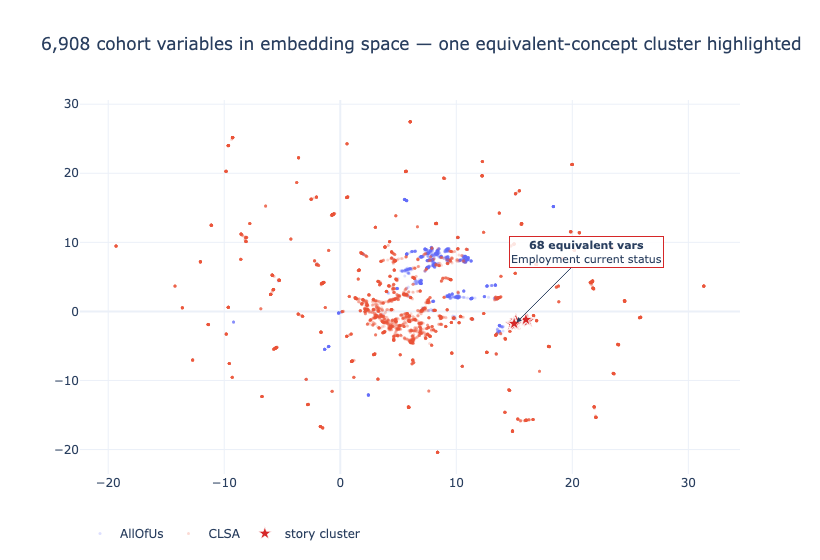

In [10]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "png"  # embed static images so the figures render on GitHub
from ddharmon.export.visualization import compute_umap_coords


def members(rec):
    """Parse a record's member_variable_names ("cohort:var") into (cohort, var) pairs."""
    out = []
    for mv in rec.member_variable_names:
        coh, _, var = mv.partition(":")
        out.append((coh, var))
    return out


# 2D UMAP of every clustered cohort variable (reuse the pipeline's own embeddings)
umap_xy = np.asarray(compute_umap_coords(tm.embeddings, random_state=42))
cohort_of = [r.dictionary_name for r in tm.field_refs]
row_of = {(r.dictionary_name, r.variable_name): i for i, r in enumerate(tm.field_refs)}

# pick a representative cluster to narrate: cross-cohort, assigned to a CDE, and sizeable
story = sorted(
    result.records,
    key=lambda r: (r.cross_cohort, r.verdict in ("adopt", "refine"), r.n_members),
    reverse=True,
)[0]
story_records = [r for r in result.records if r.cluster_id == story.cluster_id]
story_rows = [row_of[k] for r in story_records for k in members(r) if k in row_of]

# Figure A — the map: all variables in embedding space, the story cluster highlighted
figA = go.Figure()
for coh in sorted(set(cohort_of)):
    ix = [i for i, c in enumerate(cohort_of) if c == coh]
    figA.add_scatter(x=umap_xy[ix, 0], y=umap_xy[ix, 1], mode="markers", name=coh,
                     marker=dict(size=3, opacity=0.22))
if story_rows:
    sx, sy = umap_xy[story_rows, 0], umap_xy[story_rows, 1]
    figA.add_scatter(x=sx, y=sy, mode="markers", name="story cluster",
                     marker=dict(size=10, color="#d62728", symbol="star", line=dict(width=0.8, color="white")))
    lbl = story.cde_id or (story.ideal_cde[:30] + "…")
    figA.add_annotation(x=float(sx.mean()), y=float(sy.mean()),
                        text=f"<b>{len(story_rows)} equivalent vars</b><br>{lbl}",
                        showarrow=True, arrowhead=2, ax=70, ay=-70, font=dict(size=11),
                        bgcolor="rgba(255,255,255,0.85)", bordercolor="#d62728", borderwidth=1)
figA.update_layout(template="plotly_white", width=820, height=560,
                   title=f"{len(tm.field_refs):,} cohort variables in embedding space — one equivalent-concept cluster highlighted",
                   legend=dict(orientation="h", y=-0.12))
figA.show()

INFO: Chromium init'ed with kwargs {}


INFO: Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


INFO: Temp directory created: /var/folders/p2/2f6_13bn2yq88l4k55nd2vp00000gn/T/tmp_mb_yczz.


INFO: Opening browser.


INFO: Temp directory created: /var/folders/p2/2f6_13bn2yq88l4k55nd2vp00000gn/T/tmp4rs7g1ie.


...

INFO: shutil.rmtree worked.


INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: Cancelling tasks.


INFO: Exiting Kaleido/Choreo


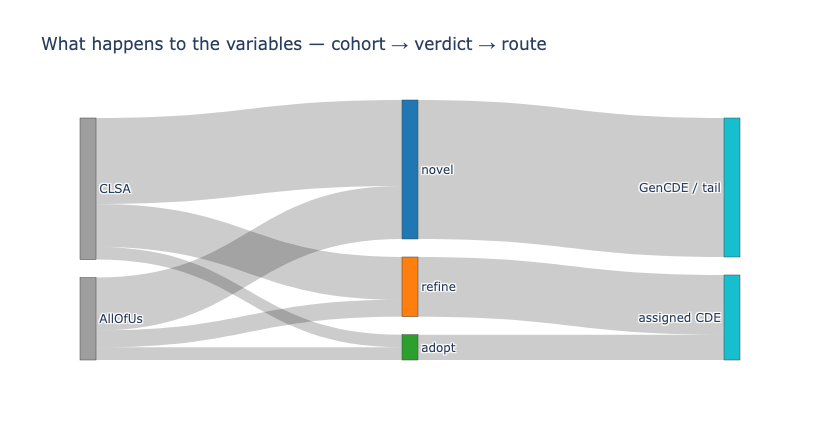

In [11]:
from collections import defaultdict

# Figure B — routing Sankey: the whole harmonized set, cohort -> verdict -> route
verdicts = ["adopt", "refine", "novel"]
vcolor = {"adopt": "#2ca02c", "refine": "#ff7f0e", "novel": "#1f77b4"}
cohort_nodes = sorted({c for r in result.records for c in r.cohorts})
route_nodes = sorted({r.route for r in result.records})
labels = cohort_nodes + verdicts + route_nodes
node_i = {name: i for i, name in enumerate(labels)}
flow_cv, flow_vr = defaultdict(float), defaultdict(float)
for r in result.records:
    v = r.verdict if r.verdict in verdicts else "novel"
    share = r.n_members / max(len(r.cohorts), 1)
    for c in r.cohorts:
        flow_cv[(c, v)] += share
    flow_vr[(v, r.route)] += r.n_members
src, tgt, val = [], [], []
for (c, v), w in flow_cv.items():
    src, tgt, val = src + [node_i[c]], tgt + [node_i[v]], val + [w]
for (v, rt), w in flow_vr.items():
    src, tgt, val = src + [node_i[v]], tgt + [node_i[rt]], val + [w]
disp = [name.replace("gencde_residual", "GenCDE / tail").replace("assigned", "assigned CDE") for name in labels]
ncolor = ["#9e9e9e"] * len(cohort_nodes) + [vcolor[v] for v in verdicts] + ["#17becf"] * len(route_nodes)
figB = go.Figure(go.Sankey(node=dict(label=disp, color=ncolor, pad=18, thickness=16),
                           link=dict(source=src, target=tgt, value=val)))
figB.update_layout(width=820, height=440, font_size=12,
                   title="What happens to the variables — cohort → verdict → route")
figB.show()

INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: Chromium init'ed with kwargs {}


...

INFO: shutil.rmtree worked.


INFO: TemporaryDirectory.cleanup() worked.


INFO: shutil.rmtree worked.


INFO: Cancelling tasks.


INFO: Exiting Kaleido/Choreo


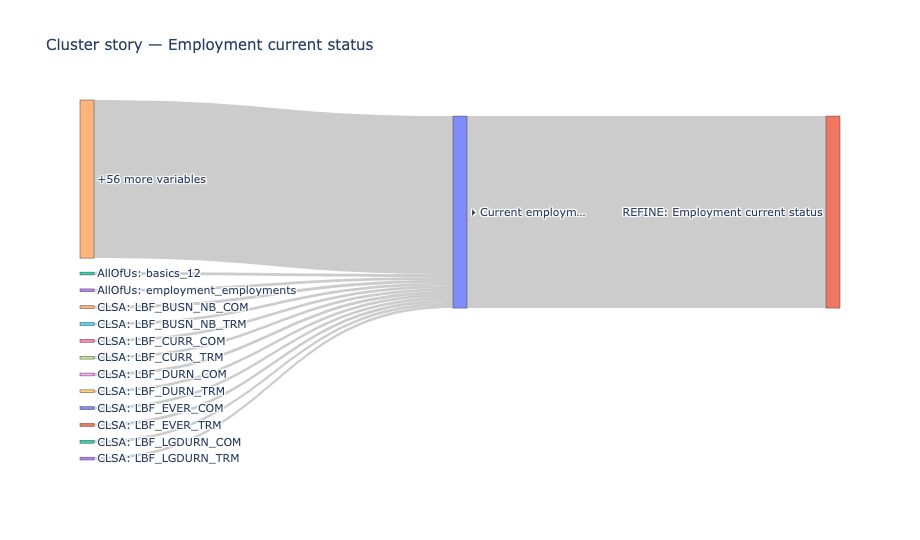

In [12]:
# Figure C — the one-cluster story: member variables -> concept-group -> verdict / CDE
def grp_label(r):
    """Concept-group node label — fall back to the generated ideal / CDE when the concept is blank."""
    return r.concept or (r.ideal_cde.split(":")[0][:30] if r.ideal_cde else (r.cde_id or "concept group"))


story_title = story.cde_id or story.concept or (story.ideal_cde[:46] + "…")
print(f"Cluster {story.cluster_id}: {sum(r.n_members for r in story_records)} variables "
      f"from {sorted({c for r in story_records for c in r.cohorts})}")
if story.ideal_cde:
    print(f"generated ideal CDE: {story.ideal_cde[:110]}")
for r in story_records:
    tag = f"  →  {r.cde_id}" if r.cde_id else ""
    print(f"\n  concept-group «{grp_label(r)[:50]}» → {r.verdict.upper()}{tag}")
    for coh, var in members(r)[:8]:
        print(f"      • {coh}: {var}")

node_labels, node_key = [], {}


def node(key, label=None):
    if key not in node_key:
        node_key[key] = len(node_labels)
        node_labels.append(label if label is not None else key)
    return node_key[key]


CAP = 12
src, tgt, val = [], [], []
for r in story_records:
    grp = node(f"grp::{r.group_id}", f"▸ {grp_label(r)[:15]}…")
    end = node(f"end::{r.group_id}", f"{r.verdict.upper()}: {str(r.cde_id)[:28]}" if r.cde_id else r.verdict.upper())
    mem = members(r)
    for coh, var in mem[:CAP]:
        src, tgt, val = src + [node(f"{coh}:{var}", f"{coh}: {var[:22]}")], tgt + [grp], val + [1]
    extra = len(mem) - CAP
    if extra > 0:
        src, tgt, val = src + [node(f"extra::{r.group_id}", f"+{extra} more variables")], tgt + [grp], val + [extra]
    src, tgt, val = src + [grp], tgt + [end], val + [len(mem)]
figC = go.Figure(go.Sankey(node=dict(label=node_labels, pad=14, thickness=14),
                           link=dict(source=src, target=tgt, value=val)))
figC.update_layout(width=920, height=540, font_size=11, title=f"Cluster story — {story_title}")
figC.show()